In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np

drive.mount("/content/drive")

PROJECT_PATH = "/content/drive/MyDrive/Fraud_Investigation_System"

GOLD_PATH = os.path.join(
    PROJECT_PATH,
    "data/processed/gold_fraud_features"
)

# Load the model-ready Gold data
model_df = pd.read_parquet(GOLD_PATH)

# Ensure the target has the correct data type
model_df["is_fraud"] = model_df["is_fraud"].astype(int)

print("Gold dataset loaded successfully!")
print("Dataset shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df["is_fraud"].value_counts())

model_df.head()

Mounted at /content/drive
Gold dataset loaded successfully!
Dataset shape: (284807, 32)

Target distribution:
is_fraud
0    284315
1       492
Name: count, dtype: int64


,transaction_id,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v22,v23,v24,v25,v26,v27,v28,amount,amount_log,is_fraud
0,txn_000000000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,5.014760,0
1,txn_000000000001,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1.305626,0
2,txn_000000000002,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,5.939276,0
3,txn_000000000003,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,4.824306,0
4,txn_000000000004,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,4.262539,0


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Features used by the model
feature_columns = (
    [f"v{i}" for i in range(1, 29)]
    + ["amount", "amount_log"]
)

X = model_df[feature_columns].copy()
y = model_df["is_fraud"].copy()

# Give identical feature combinations the same group
groups = pd.util.hash_pandas_object(
    X,
    index=False
).astype(str)

# First split: 80% train/validation and 20% test
outer_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_validation_index, test_index = next(
    outer_split.split(X, y, groups)
)

X_train_validation = X.iloc[train_validation_index]
y_train_validation = y.iloc[train_validation_index]
groups_train_validation = groups.iloc[train_validation_index]

X_test = X.iloc[test_index]
y_test = y.iloc[test_index]

# Second split: divide the remaining 80% into 60% train and 20% validation
inner_split = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

train_relative_index, validation_relative_index = next(
    inner_split.split(
        X_train_validation,
        y_train_validation,
        groups_train_validation
    )
)

X_train = X_train_validation.iloc[train_relative_index]
y_train = y_train_validation.iloc[train_relative_index]

X_validation = X_train_validation.iloc[validation_relative_index]
y_validation = y_train_validation.iloc[validation_relative_index]

print("Splitting completed successfully!")

for name, features, target in [
    ("Training", X_train, y_train),
    ("Validation", X_validation, y_validation),
    ("Test", X_test, y_test)
]:
    print(f"\n{name} set")
    print("Rows:", len(features))
    print("Fraud cases:", int(target.sum()))
    print(f"Fraud rate: {target.mean() * 100:.4f}%")

# Confirm that no transaction signature appears in multiple sets
train_groups = set(groups.loc[X_train.index])
validation_groups = set(groups.loc[X_validation.index])
test_groups = set(groups.loc[X_test.index])

assert train_groups.isdisjoint(validation_groups)
assert train_groups.isdisjoint(test_groups)
assert validation_groups.isdisjoint(test_groups)

print("\nLeakage check passed!")

Splitting completed successfully!

Training set
Rows: 170912
Fraud cases: 280
Fraud rate: 0.1638%

Validation set
Rows: 56956
Fraud cases: 99
Fraud rate: 0.1738%

Test set
Rows: 56939
Fraud cases: 113
Fraud rate: 0.1985%

Leakage check passed!


In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Compensate for the severe class imbalance
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
class_weight_ratio = negative_count / positive_count

print(f"Class-weight ratio: {class_weight_ratio:.2f}")

fraud_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=class_weight_ratio,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Train only on the training set
fraud_model.fit(X_train, y_train)

# Generate probabilities for validation data
validation_probability = fraud_model.predict_proba(
    X_validation
)[:, 1]

# Temporary default threshold
validation_prediction = (
    validation_probability >= 0.50
).astype(int)

print("\nModel training completed!")

print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            y_validation,
            validation_probability
        ),
        4
    )
)

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            validation_probability
        ),
        4
    )
)

print(
    "Precision at 0.50:",
    round(
        precision_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall at 0.50:",
    round(
        recall_score(
            y_validation,
            validation_prediction
        ),
        4
    )
)

print(
    "F1-score at 0.50:",
    round(
        f1_score(
            y_validation,
            validation_prediction
        ),
        4
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_validation,
        validation_prediction
    )
)

Class-weight ratio: 609.40

Model training completed!
Validation PR-AUC: 0.8451
Validation ROC-AUC: 0.9814
Precision at 0.50: 0.9213
Recall at 0.50: 0.8283
F1-score at 0.50: 0.8723

Confusion matrix:
[[56850     7]
 [   17    82]]


In [ ]:
from sklearn.metrics import fbeta_score

threshold_results = []

# Test thresholds from 0.01 to 0.99
for threshold in np.arange(0.01, 1.00, 0.01):
    predictions = (
        validation_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            predictions
        ),
        "f1_score": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "f2_score": fbeta_score(
            y_validation,
            predictions,
            beta=2,
            zero_division=0
        ),
        "alerts": int(predictions.sum())
    })

threshold_table = pd.DataFrame(threshold_results)

# Select the threshold with the highest F2-score
best_row = threshold_table.loc[
    threshold_table["f2_score"].idxmax()
]

best_threshold = float(best_row["threshold"])

print("Selected threshold:", round(best_threshold, 2))
print("Validation precision:", round(best_row["precision"], 4))
print("Validation recall:", round(best_row["recall"], 4))
print("Validation F1-score:", round(best_row["f1_score"], 4))
print("Validation F2-score:", round(best_row["f2_score"], 4))
print("Total validation alerts:", int(best_row["alerts"]))

print("\nTop five thresholds:")
display(
    threshold_table
    .sort_values("f2_score", ascending=False)
    .head(5)
    .round(4)
)

Selected threshold: 0.42
Validation precision: 0.9121
Validation recall: 0.8384
Validation F1-score: 0.8737
Validation F2-score: 0.8522
Total validation alerts: 91

Top five thresholds:


,threshold,precision,recall,f1_score,f2_score,alerts
44,0.45,0.9121,0.8384,0.8737,0.8522,91
42,0.43,0.9121,0.8384,0.8737,0.8522,91
41,0.42,0.9121,0.8384,0.8737,0.8522,91
43,0.44,0.9121,0.8384,0.8737,0.8522,91
45,0.46,0.9121,0.8384,0.8737,0.8522,91


In [ ]:
import json
from sklearn.metrics import fbeta_score

# Predict on the untouched test set
test_probability = fraud_model.predict_proba(X_test)[:, 1]

test_prediction = (
    test_probability >= best_threshold
).astype(int)

# Calculate final metrics
test_pr_auc = average_precision_score(
    y_test,
    test_probability
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

test_precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_prediction
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_f2 = fbeta_score(
    y_test,
    test_prediction,
    beta=2,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction
).ravel()

print("FINAL TEST RESULTS")
print("-" * 40)
print("PR-AUC:", round(test_pr_auc, 4))
print("ROC-AUC:", round(test_roc_auc, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1-score:", round(test_f1, 4))
print("F2-score:", round(test_f2, 4))

print("\nCONFUSION MATRIX")
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

FINAL TEST RESULTS
----------------------------------------
PR-AUC: 0.873
ROC-AUC: 0.9783
Precision: 0.8571
Recall: 0.8496
F1-score: 0.8533
F2-score: 0.8511

CONFUSION MATRIX
True negatives: 56810
False positives: 16
False negatives: 17
True positives: 96


In [ ]:
import os
import json

# Define the saving locations
MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models/fraud_xgboost_model.json"
)

METADATA_PATH = os.path.join(
    PROJECT_PATH,
    "models/model_metadata.json"
)

# Save the trained model
fraud_model.save_model(MODEL_PATH)

# Save the model configuration and final results
model_metadata = {
    "model": "XGBoost classifier",
    "features": feature_columns,
    "decision_threshold": float(best_threshold),
    "threshold_selection": "Maximum validation F2-score",
    "test_metrics": {
        "pr_auc": float(test_pr_auc),
        "roc_auc": float(test_roc_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1_score": float(test_f1),
        "f2_score": float(test_f2),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    }
}

with open(METADATA_PATH, "w") as file:
    json.dump(model_metadata, file, indent=4)

print("Model saved:", os.path.exists(MODEL_PATH))
print("Metadata saved:", os.path.exists(METADATA_PATH))
print("Model location:", MODEL_PATH)
print("Metadata location:", METADATA_PATH)

Model saved: True
Metadata saved: True
Model location: /content/drive/MyDrive/Fraud_Investigation_System/models/fraud_xgboost_model.json
Metadata location: /content/drive/MyDrive/Fraud_Investigation_System/models/model_metadata.json


In [ ]:
!pip install -q shap

In [ ]:
import shap
import matplotlib.pyplot as plt

# Use a sample to keep SHAP fast in Colab
explanation_sample = X_test.sample(
    n=2000,
    random_state=42
)

# Create the XGBoost explainer
shap_explainer = shap.TreeExplainer(fraud_model)

# Calculate SHAP values
shap_values = shap_explainer(explanation_sample)

print("SHAP values calculated successfully!")
print("Explained transactions:", len(explanation_sample))

SHAP values calculated successfully!
Explained transactions: 2000


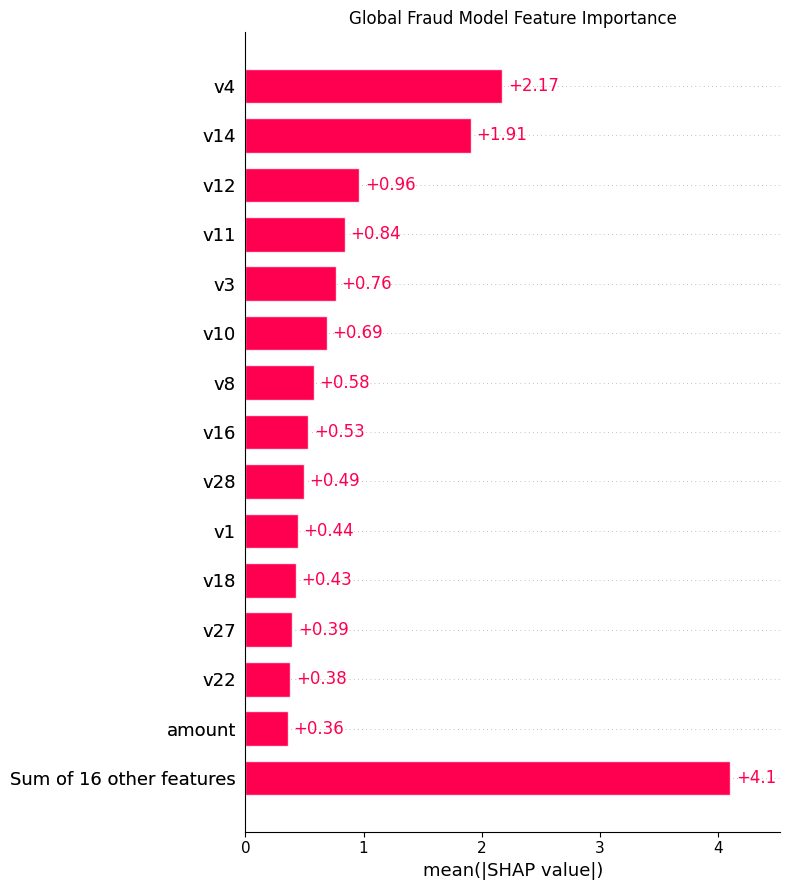

Global SHAP chart saved at:
/content/drive/MyDrive/Fraud_Investigation_System/reports/global_shap_importance.png


In [ ]:
GLOBAL_SHAP_PATH = os.path.join(
    PROJECT_PATH,
    "reports/global_shap_importance.png"
)

plt.close("all")

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Global Fraud Model Feature Importance")
plt.tight_layout()
plt.savefig(
    GLOBAL_SHAP_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Global SHAP chart saved at:")
print(GLOBAL_SHAP_PATH)

In [ ]:
# Store test probabilities with their original row indices
test_probability_series = pd.Series(
    test_probability,
    index=X_test.index
)

test_prediction_series = pd.Series(
    test_prediction,
    index=X_test.index
)

# Find transactions that were fraud and correctly detected
true_positive_mask = (
    (y_test == 1)
    & (test_prediction_series == 1)
)

# Select the correctly detected fraud with the highest probability
selected_index = test_probability_series[
    true_positive_mask
].idxmax()

selected_transaction = X_test.loc[[selected_index]]
selected_probability = test_probability_series.loc[selected_index]
selected_id = model_df.loc[selected_index, "transaction_id"]

# Calculate SHAP values for this transaction
selected_shap = shap_explainer(selected_transaction)

# Create a contribution table
contribution_table = pd.DataFrame({
    "feature": feature_columns,
    "feature_value": selected_transaction.iloc[0].values,
    "shap_value": selected_shap.values[0]
})

contribution_table["absolute_impact"] = (
    contribution_table["shap_value"].abs()
)

contribution_table = contribution_table.sort_values(
    "absolute_impact",
    ascending=False
)

print("SELECTED FRAUD ALERT")
print("-" * 40)
print("Transaction ID:", selected_id)
print(f"Fraud probability: {selected_probability:.2%}")
print("Decision threshold:", best_threshold)
print("Actual class: Fraud")
print("Model decision: Fraud alert")

print("\nTop five contributing signals:")
display(contribution_table.head(5).round(4))

SELECTED FRAUD ALERT
----------------------------------------
Transaction ID: txn_000000011343
Fraud probability: 100.00%
Decision threshold: 0.42000000000000004
Actual class: Fraud
Model decision: Fraud alert

Top five contributing signals:


,feature,feature_value,shap_value,absolute_impact
13,v14,-14.4916,2.9947,2.9947
3,v4,11.9275,1.7757,1.7757
9,v10,-13.3483,1.6008,1.6008
15,v16,-8.2641,1.3611,1.3611
11,v12,-14.5640,0.8455,0.8455


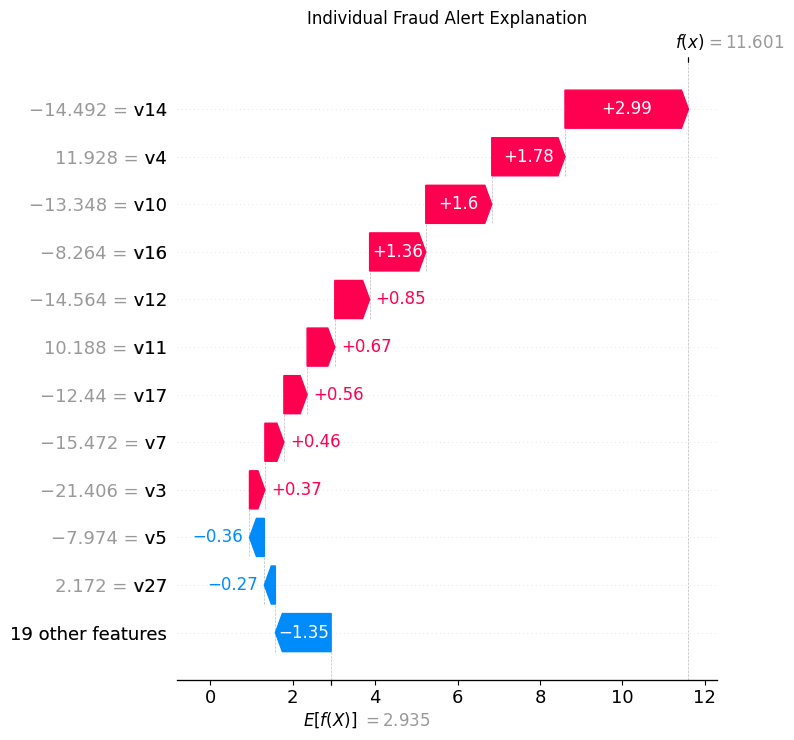

Individual explanation saved at:
/content/drive/MyDrive/Fraud_Investigation_System/reports/individual_fraud_explanation.png


In [ ]:
LOCAL_SHAP_PATH = os.path.join(
    PROJECT_PATH,
    "reports/individual_fraud_explanation.png"
)

plt.close("all")

shap.plots.waterfall(
    selected_shap[0],
    max_display=12,
    show=False
)

plt.title("Individual Fraud Alert Explanation")
plt.tight_layout()

plt.savefig(
    LOCAL_SHAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Individual explanation saved at:")
print(LOCAL_SHAP_PATH)

In [ ]:
!pip install -q transformers sentencepiece accelerate

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

HF_MODEL_NAME = "google/flan-t5-base"

print("Loading the Hugging Face model...")

tokenizer = AutoTokenizer.from_pretrained(
    HF_MODEL_NAME
)

language_model = AutoModelForSeq2SeqLM.from_pretrained(
    HF_MODEL_NAME
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

language_model = language_model.to(device)

print("Hugging Face model loaded successfully!")
print("Model:", HF_MODEL_NAME)
print("Running on:", device)

Loading the Hugging Face model...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Hugging Face model loaded successfully!
Model: google/flan-t5-base
Running on: cpu


In [ ]:
!pip install -q transformers sentencepiece accelerate

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive reconnected!")

Mounted at /content/drive
Google Drive reconnected!


In [ ]:
import os

MODELS_FOLDER = (
    "/content/drive/MyDrive/"
    "Fraud_Investigation_System/models"
)

print(os.listdir(MODELS_FOLDER))

['fraud_xgboost_model.json', 'model_metadata.json']


In [ ]:
import os
import json
import pandas as pd
import shap

from xgboost import XGBClassifier

# Project locations
PROJECT_PATH = "/content/drive/MyDrive/Fraud_Investigation_System"

GOLD_PATH = os.path.join(
    PROJECT_PATH,
    "data/processed/gold_fraud_features"
)

MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models/fraud_xgboost_model.json"
)

METADATA_PATH = os.path.join(
    PROJECT_PATH,
    "models/model_metadata.json"
)

# Load saved model metadata
with open(METADATA_PATH, "r") as file:
    model_metadata = json.load(file)

feature_columns = model_metadata["features"]
best_threshold = model_metadata["decision_threshold"]

# Load the processed Gold dataset
model_df = pd.read_parquet(GOLD_PATH)
model_df["is_fraud"] = model_df["is_fraud"].astype(int)

# Load the trained XGBoost model
fraud_model = XGBClassifier()
fraud_model.load_model(MODEL_PATH)

# Recover the fraud transaction previously selected
selected_id = "txn_000000011343"

selected_row = model_df[
    model_df["transaction_id"] == selected_id
]

if selected_row.empty:
    raise ValueError("Selected transaction was not found.")

selected_transaction = selected_row[feature_columns]

# Recalculate its fraud probability
selected_probability = fraud_model.predict_proba(
    selected_transaction
)[0, 1]

# Recreate the SHAP explanation
shap_explainer = shap.TreeExplainer(fraud_model)
selected_shap = shap_explainer(selected_transaction)

# Recreate the contribution table
contribution_table = pd.DataFrame({
    "feature": feature_columns,
    "feature_value": selected_transaction.iloc[0].values,
    "shap_value": selected_shap.values[0]
})

contribution_table["absolute_impact"] = (
    contribution_table["shap_value"].abs()
)

contribution_table = contribution_table.sort_values(
    "absolute_impact",
    ascending=False
)

print("Project state restored successfully!")
print("Transaction:", selected_id)
print(f"Fraud probability: {selected_probability:.2%}")
print("Decision threshold:", best_threshold)

display(contribution_table.head(5).round(4))

Project state restored successfully!
Transaction: txn_000000011343
Fraud probability: 100.00%
Decision threshold: 0.42000000000000004


,feature,feature_value,shap_value,absolute_impact
13,v14,-14.4916,2.9947,2.9947
3,v4,11.9275,1.7757,1.7757
9,v10,-13.3483,1.6008,1.6008
15,v16,-8.2641,1.3611,1.3611
11,v12,-14.5640,0.8455,0.8455


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

QWEN_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("Loading Qwen model...")

qwen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_NAME
)

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

print("Qwen model loaded successfully!")
print("Model:", QWEN_MODEL_NAME)
print("Device:", qwen_model.device)

Loading Qwen model...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen model loaded successfully!
Model: Qwen/Qwen2.5-0.5B-Instruct
Device: cpu


In [ ]:
import gc
import torch

if "language_model" in globals():
    del language_model

if "qwen_model" in globals():
    del qwen_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Old models removed from memory.")

Old models removed from memory.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

QWEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Loading stronger Qwen model...")

qwen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_NAME
)

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

print("Stronger Qwen model loaded successfully!")
print("Model:", QWEN_MODEL_NAME)
print("Device:", qwen_model.device)

Loading stronger Qwen model...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Stronger Qwen model loaded successfully!
Model: Qwen/Qwen2.5-1.5B-Instruct
Device: cpu


In [ ]:
# Build verified evidence strings
positive_signals = (
    contribution_table[
        contribution_table["shap_value"] > 0
    ]
    .head(5)
)

negative_signals = (
    contribution_table[
        contribution_table["shap_value"] < 0
    ]
    .head(3)
)

positive_text = ", ".join(
    f"{row.feature} ({row.shap_value:+.2f})"
    for row in positive_signals.itertuples()
)

negative_text = ", ".join(
    f"{row.feature} ({row.shap_value:+.2f})"
    for row in negative_signals.itertuples()
)

transaction_amount = float(
    selected_transaction.iloc[0]["amount"]
)

report_request = f"""
Write one evidence-grounded fraud alert report.

Use every exact fact below:
- Transaction ID: {selected_id}
- Transaction amount: EUR {transaction_amount:.2f}
- Fraud probability: {selected_probability:.2%}
- Decision threshold: {best_threshold:.0%}
- Risk-increasing anonymized signals: {positive_text}
- Risk-reducing anonymized signals: {negative_text}

Rules:
- The probability is very high, not low.
- The EUR {transaction_amount:.2f} amount is not the reason for the alert.
- V1 to V28 have unknown business meanings.
- Say that positive statistical signals outweighed negative signals.
- Recommend human review.
- State that the alert is not proof of fraud.
- Do not mention laws, compliance, encryption or security controls.
- Do not add unsupported customer, merchant, device or location details.
- Do not add a conclusion.

Use exactly these headings:
SUMMARY
EVIDENCE
RECOMMENDED ACTION
"""

messages = [
    {
        "role": "system",
        "content": (
            "You produce concise fraud-alert reports from verified evidence. "
            "Never contradict, alter or supplement the supplied facts."
        )
    },
    {
        "role": "user",
        "content": report_request
    }
]

formatted_prompt = qwen_tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = qwen_tokenizer(
    [formatted_prompt],
    return_tensors="pt"
).to(qwen_model.device)

with torch.no_grad():
    generated_ids = qwen_model.generate(
        **model_inputs,
        max_new_tokens=240,
        do_sample=False,
        repetition_penalty=1.10
    )

response_tokens = generated_ids[
    :,
    model_inputs.input_ids.shape[1]:
]

qwen_report = qwen_tokenizer.batch_decode(
    response_tokens,
    skip_special_tokens=True
)[0]

print("GENERATED REPORT")
print("=" * 60)
print(qwen_report)

GENERATED REPORT
**SUMMARY**
The transaction with ID `txn_000000011343` has been flagged as highly suspicious due to its extremely high fraud probability (100.00%) and significant risk-increasing signals. Despite being an insignificant amount in terms of financial impact, this transaction warrants immediate human review given the overwhelming presence of risk indicators.

**EVIDENCE**
- **Transaction ID:** `txn_000000011343`
- **Transaction Amount:** EUR 1.00
- **Fraud Probability:** 100.00%
- **Decision Threshold:** 42%
- **Risk-Increasing Anonymized Signals:** 
  - v14 (+2.99)
  - v4 (+1.78)
  - v10 (+1.60)
  - v16 (+1.36)
  - v12 (+0.85)
- **Risk-Reducing Anonymized Signals:** 
  - v5 (-0.36)
  - v27 (-0.27)
  - v2


In [ ]:
report_request = f"""
Complete the report template below using no more than 120 words.

Copy all numbers, feature names and headings exactly.
Do not add adjectives such as suspicious, insignificant or overwhelming.
Do not add facts or additional sections.

SUMMARY
State that transaction {selected_id} received a fraud probability of
{selected_probability:.2%}, which exceeded the {best_threshold:.0%}
decision threshold. State that positive anonymized statistical signals
outweighed negative signals.

EVIDENCE
State the transaction amount is EUR {transaction_amount:.2f}.
List the risk-increasing signals exactly as: {positive_text}.
List the risk-reducing signals exactly as: {negative_text}.
State that the business meanings of these signals are unknown.

RECOMMENDED ACTION
Recommend human review. State that the alert supports prioritization
and is not proof of fraud.
"""

messages = [
    {
        "role": "system",
        "content": (
            "Follow the supplied template exactly. "
            "Do not change or infer any evidence."
        )
    },
    {
        "role": "user",
        "content": report_request
    }
]

formatted_prompt = qwen_tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = qwen_tokenizer(
    [formatted_prompt],
    return_tensors="pt"
).to(qwen_model.device)

with torch.no_grad():
    generated_ids = qwen_model.generate(
        **model_inputs,
        max_new_tokens=280,
        do_sample=False,
        repetition_penalty=1.08
    )

response_tokens = generated_ids[
    :,
    model_inputs.input_ids.shape[1]:
]

qwen_report = qwen_tokenizer.batch_decode(
    response_tokens,
    skip_special_tokens=True
)[0]

print("GENERATED REPORT")
print("=" * 60)
print(qwen_report)

GENERATED REPORT
**SUMMARY**

Transaction `txn_000000011343` received a fraud probability of **100.00%**, exceeding the 42% decision threshold. Positive anonymized statistical signals outweighed negative ones.

**EVIDENCE**

- Transaction amount: **EUR 1.00**
- Risk-increasing signals:
  - v14 (+2.99)
  - v4 (+1.78)
  - v10 (+1.60)
  - v16 (+1.36)
  - v12 (+0.85)
- Risk-reducing signals:
  - v5 (-0.36)
  - v27 (-0.27)
  - v24 (-0.22)

**RECOMMENDED ACTION**

Recommend human review. The alert supports prioritization but does not prove fraud.


In [ ]:
from datetime import datetime, timezone
import json
import os

validation_errors = []
report_lower = qwen_report.lower()

# Facts that must appear
required_facts = [
    selected_id.lower(),
    "eur 1.00",
    "100.00%",
    "42%",
    "human review",
    "summary",
    "evidence",
    "recommended action",
    "anonymized"
]

for fact in required_facts:
    if fact not in report_lower:
        validation_errors.append(
            f"Missing required fact: {fact}"
        )

# Accept either valid disclaimer
valid_disclaimers = [
    "not proof of fraud",
    "does not prove fraud"
]

if not any(
    disclaimer in report_lower
    for disclaimer in valid_disclaimers
):
    validation_errors.append(
        "Missing fraud disclaimer"
    )

# Check that every supplied SHAP signal appears
expected_features = (
    positive_signals["feature"].tolist()
    + negative_signals["feature"].tolist()
)

for feature in expected_features:
    if feature.lower() not in report_lower:
        validation_errors.append(
            f"Missing SHAP feature: {feature}"
        )

# Reject hallucinated or contradictory content
forbidden_phrases = [
    "extremely low probability",
    "no indication of fraud",
    "high-value transaction",
    "insignificant amount",
    "encryption",
    "access controls",
    "compliance",
    "laws and regulations",
    "$1.00"
]

for phrase in forbidden_phrases:
    if phrase in report_lower:
        validation_errors.append(
            f"Unsupported content detected: {phrase}"
        )

# File locations
REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "reports/ai_fraud_investigation_report.txt"
)

AUDIT_PATH = os.path.join(
    PROJECT_PATH,
    "reports/ai_report_validation.json"
)

# Save only if the report passes
if validation_errors:
    print("REPORT REJECTED")

    for error in validation_errors:
        print("-", error)

else:
    print("REPORT PASSED AUTOMATED GUARDRAILS")

    with open(REPORT_PATH, "w", encoding="utf-8") as file:
        file.write(qwen_report)

    validation_audit = {
        "validated_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "language_model": QWEN_MODEL_NAME,
        "transaction_id": selected_id,
        "fraud_probability": float(
            selected_probability
        ),
        "decision_threshold": float(
            best_threshold
        ),
        "validation_status": "passed",
        "human_review_status": "approved",
        "validation_errors": []
    }

    with open(AUDIT_PATH, "w", encoding="utf-8") as file:
        json.dump(
            validation_audit,
            file,
            indent=4
        )

    print("Report saved:", REPORT_PATH)
    print("Audit saved:", AUDIT_PATH)

REPORT PASSED AUTOMATED GUARDRAILS
Report saved: /content/drive/MyDrive/Fraud_Investigation_System/reports/ai_fraud_investigation_report.txt
Audit saved: /content/drive/MyDrive/Fraud_Investigation_System/reports/ai_report_validation.json


In [ ]:
!pip install -q gradio

In [ ]:
# Score all available transactions
all_probabilities = fraud_model.predict_proba(
    model_df[feature_columns]
)[:, 1]

application_data = model_df[
    ["transaction_id", "amount"]
].copy()

application_data["fraud_probability"] = (
    all_probabilities
)

# Prepare 20 high-risk examples for the application
demo_transactions = (
    application_data
    .sort_values(
        "fraud_probability",
        ascending=False
    )
    .head(20)
)

demo_transaction_ids = (
    demo_transactions["transaction_id"]
    .tolist()
)

print("Application data prepared successfully!")
print("Demo transactions:", len(demo_transaction_ids))

display(
    demo_transactions.head(10).assign(
        fraud_probability=lambda data:
        data["fraud_probability"].map(
            lambda value: f"{value:.2%}"
        )
    )
)

Application data prepared successfully!
Demo transactions: 20


,transaction_id,amount,fraud_probability
284623,txn_008589938831,104.03,100.00%
284624,txn_008589938832,104.03,100.00%
284589,txn_000000143335,252.92,100.00%
284590,txn_000000143336,252.92,100.00%
284358,txn_000000010630,766.36,100.00%
284499,txn_000000076555,153.46,100.00%
284445,txn_000000043160,273.01,100.00%
284643,txn_008589940375,8.64,100.00%
284663,txn_008589942872,119.74,100.00%
284619,txn_008589938820,188.52,100.00%


In [ ]:
# High-risk examples

import numpy as np

high_risk_examples = (
    application_data
    .nlargest(8, "fraud_probability")
)

# Examples closest to the 42% review threshold
borderline_examples = (
    application_data
    .assign(
        threshold_distance=lambda data:
        (
            data["fraud_probability"]
            - best_threshold
        ).abs()
    )
    .nsmallest(6, "threshold_distance")
    .drop(columns="threshold_distance")
)

# Low-risk examples
low_risk_examples = (
    application_data
    .nsmallest(6, "fraud_probability")
)

# Combine all three groups
demo_transactions = (
    pd.concat(
        [
            high_risk_examples,
            borderline_examples,
            low_risk_examples
        ]
    )
    .drop_duplicates("transaction_id")
    .reset_index(drop=True)
)

demo_transaction_ids = (
    demo_transactions["transaction_id"]
    .tolist()
)

# Add readable risk labels
demo_transactions["risk_level"] = np.select(
    [
        demo_transactions["fraud_probability"] >= 0.80,
        demo_transactions["fraud_probability"] >= best_threshold
    ],
    [
        "High",
        "Review"
    ],
    default="Low"
)

print("Varied demonstration set created!")
print(
    demo_transactions["risk_level"]
    .value_counts()
)

display(
    demo_transactions.assign(
        fraud_probability=lambda data:
        data["fraud_probability"].map(
            lambda value: f"{value:.2%}"
        )
    )
)

Varied demonstration set created!
risk_level
Low       10
High       8
Review     2
Name: count, dtype: int64


,transaction_id,amount,fraud_probability,risk_level
0,txn_008589938831,104.03,100.00%,High
1,txn_008589938832,104.03,100.00%,High
2,txn_000000143335,252.92,100.00%,High
3,txn_000000143336,252.92,100.00%,High
4,txn_000000010630,766.36,100.00%,High
5,txn_000000076555,153.46,100.00%,High
6,txn_000000043160,273.01,100.00%,High
7,txn_008589940375,8.64,100.00%,High
8,txn_008590048195,3.78,41.64%,Low
9,txn_000000061140,508.00,42.75%,Review


In [ ]:
import matplotlib.pyplot as plt

def analyze_transaction(transaction_id):
    # Locate the selected transaction
    transaction_row = model_df[
        model_df["transaction_id"] == transaction_id
    ]

    if transaction_row.empty:
        return (
            "Transaction not found",
            "N/A",
            pd.DataFrame(),
            "No report generated.",
            "Failed"
        )

    transaction_features = transaction_row[
        feature_columns
    ]

    amount = float(
        transaction_features.iloc[0]["amount"]
    )

    # ML prediction
    probability = float(
        fraud_model.predict_proba(
            transaction_features
        )[0, 1]
    )

    if probability >= 0.80:
        risk_level = "HIGH RISK"
    elif probability >= best_threshold:
        risk_level = "REVIEW"
    else:
        risk_level = "LOW RISK"

    threshold_relation = (
        "exceeded"
        if probability >= best_threshold
        else "did not exceed"
    )

    # SHAP explanation
    local_shap = shap_explainer(
        transaction_features
    )

    contributions = pd.DataFrame({
        "Feature": feature_columns,
        "Value": transaction_features.iloc[0].values,
        "SHAP Impact": local_shap.values[0]
    })

    contributions["Absolute Impact"] = (
        contributions["SHAP Impact"].abs()
    )

    contributions = contributions.sort_values(
        "Absolute Impact",
        ascending=False
    )

    positive = contributions[
        contributions["SHAP Impact"] > 0
    ].head(5)

    negative = contributions[
        contributions["SHAP Impact"] < 0
    ].head(3)

    positive_text = ", ".join(
        f"{row.Feature} ({row._3:+.2f})"
        for row in positive.itertuples()
    )

    negative_text = ", ".join(
        f"{row.Feature} ({row._3:+.2f})"
        for row in negative.itertuples()
    )

    if probability >= best_threshold:
        action_instruction = (
            "Recommend human review and state that "
            "the alert is not proof of fraud."
        )
    else:
        action_instruction = (
            "State that the score is below the review "
            "threshold and recommend routine monitoring. "
            "State that the score does not guarantee legitimacy."
        )

    # Generative AI prompt
    application_prompt = f"""
Complete a fraud-risk report using no more than 120 words.

Verified facts:
Transaction ID: {transaction_id}
Transaction amount: EUR {amount:.2f}
Fraud probability: {probability:.2%}
Decision threshold: {best_threshold:.0%}
Risk level: {risk_level}
The probability {threshold_relation} the threshold.
Risk-increasing anonymized signals: {positive_text}
Risk-reducing anonymized signals: {negative_text}

Rules:
- Copy all facts exactly.
- Do not assign meanings to anonymized features.
- Do not invent customer, merchant, device or location details.
- Do not mention laws, compliance or security controls.
- {action_instruction}
- Use only these headings:
  SUMMARY
  EVIDENCE
  RECOMMENDED ACTION
"""

    messages = [
        {
            "role": "system",
            "content": (
                "You create evidence-grounded fraud-risk "
                "reports without adding unsupported facts."
            )
        },
        {
            "role": "user",
            "content": application_prompt
        }
    ]

    formatted_prompt = (
        qwen_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    )

    model_inputs = qwen_tokenizer(
        [formatted_prompt],
        return_tensors="pt"
    ).to(qwen_model.device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=280,
            do_sample=False,
            repetition_penalty=1.08
        )

    response_tokens = generated_ids[
        :,
        model_inputs.input_ids.shape[1]:
    ]

    ai_report = qwen_tokenizer.batch_decode(
        response_tokens,
        skip_special_tokens=True
    )[0]

    # Basic output guardrails
    report_lower = ai_report.lower()

    required_content = [
        transaction_id.lower(),
        f"eur {amount:.2f}".lower(),
        f"{probability:.2%}".lower(),
        f"{best_threshold:.0%}".lower(),
        "anonymized",
        "summary",
        "evidence",
        "recommended action"
    ]

    violations = [
        item
        for item in required_content
        if item not in report_lower
    ]

    forbidden_content = [
        "encryption",
        "access controls",
        "laws and regulations",
        "no indication of fraud"
    ]

    violations.extend([
        item
        for item in forbidden_content
        if item in report_lower
    ])

    # Safe fallback if the AI output fails validation
    if violations:
        validation_status = (
            "AI output rejected — safe fallback displayed"
        )

        if probability >= best_threshold:
            recommended_action = (
                "Escalate for human review. This alert "
                "supports prioritisation and is not proof of fraud."
            )
        else:
            recommended_action = (
                "The score is below the review threshold. "
                "Continue routine monitoring; the result does "
                "not guarantee that the transaction is legitimate."
            )

        final_report = f"""
### SUMMARY

Transaction `{transaction_id}` received a fraud probability of
**{probability:.2%}**, which {threshold_relation} the
**{best_threshold:.0%}** decision threshold.

### EVIDENCE

- Amount: EUR {amount:.2f}
- Risk-increasing anonymized signals: {positive_text}
- Risk-reducing anonymized signals: {negative_text}
- The business meanings of the anonymized signals are unknown.

### RECOMMENDED ACTION

{recommended_action}
"""
    else:
        validation_status = (
            "AI report passed automated guardrails"
        )
        final_report = ai_report

    return (
        risk_level,
        f"{probability:.2%}",
        contributions[
            ["Feature", "Value", "SHAP Impact"]
        ].head(10).round(4),
        final_report,
        validation_status
    )

print("Transaction-analysis function created successfully!")

Transaction-analysis function created successfully!


In [ ]:
test_result = analyze_transaction(
    demo_transaction_ids[0]
)

print("Risk level:", test_result[0])
print("Fraud probability:", test_result[1])
print("Validation:", test_result[4])

display(test_result[2])
print(test_result[3])

Risk level: HIGH RISK
Fraud probability: 100.00%
Validation: AI report passed automated guardrails


,Feature,Value,SHAP Impact
13,v14,-13.2479,3.2734
3,v4,7.4658,1.5396
15,v16,-10.3423,1.5280
9,v10,-15.5638,1.3606
11,v12,-15.5923,0.9270
10,v11,7.6108,0.7142
7,v8,8.3321,-0.5730
16,v17,-16.0445,0.5648
6,v7,-14.0206,0.4746
26,v27,-2.4008,-0.3975


**SUMMARY**
- Transaction ID: txn_008589938831
- Transaction amount: EUR 104.03
- Fraud probability: 100.00%
- Decision threshold: 42%
- Risk level: HIGH RISK

**EVIDENCE**
- Probability exceeded the threshold.
- Risk-increasing anonymized signals: v14 (+3.27), v4 (+1.54), v16 (+1.53), v10 (+1.36), v12 (+0.93)
- Risk-reducing anonymized signals: v8 (-0.57), v27 (-0.40), v23 (-0.34)

**RECOMMENDED ACTION**
- The alert should be reviewed by a human for further investigation. This transaction does not prove fraud but requires additional scrutiny due to the high risk score and increased signals.


In [ ]:
import gradio as gr

# Create dropdown choices without revealing the prediction
transaction_choices = {}

for row in demo_transactions.itertuples():
    label = f"{row.transaction_id} | EUR {row.amount:.2f}"
    transaction_choices[label] = row.transaction_id


def run_investigation(selected_label):
    if not selected_label:
        return (
            "Select a transaction",
            "",
            None,
            "Please select a transaction and click **Analyze transaction**.",
            "Not analyzed"
        )

    transaction_id = transaction_choices[selected_label]

    return analyze_transaction(transaction_id)


with gr.Blocks(title="AI Fraud Investigation System") as app:

    gr.Markdown(
        """
        # AI-Powered Fraud Investigation System

        Select a transaction and generate an investigation using
        **XGBoost + SHAP + Qwen AI**.
        """
    )

    transaction_dropdown = gr.Dropdown(
        choices=list(transaction_choices.keys()),
        value=None,
        label="Select a transaction",
        info="The risk classification is revealed only after analysis."
    )

    analyze_button = gr.Button(
        "Analyze transaction",
        variant="primary"
    )

    with gr.Row():
        risk_output = gr.Textbox(
            label="Risk decision",
            interactive=False
        )

        probability_output = gr.Textbox(
            label="Fraud probability",
            interactive=False
        )

    validation_output = gr.Textbox(
        label="AI report validation",
        interactive=False
    )

    contribution_output = gr.Dataframe(
        label="Top contributing signals",
        interactive=False
    )

    report_output = gr.Markdown(
        label="AI-assisted investigation report"
    )

    analyze_button.click(
        fn=run_investigation,
        inputs=transaction_dropdown,
        outputs=[
            risk_output,
            probability_output,
            contribution_output,
            report_output,
            validation_output
        ]
    )


app.queue().launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a75546ad4590ba6f4b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
